<a href="https://colab.research.google.com/github/keirajp/Ai-Minor-Project-Ai-For-Market-Trend-Analysis-/blob/main/Inventory%20and%20MRP%20Case%20analysis%20for%20IIM%20Vizag%20case%20study%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, let's install the `PyPDF2` library, which is commonly used for reading and writing PDF files in Python.

In [ ]:
!pip install PyPDF2
!pip install xlsxwriter # Install xlsxwriter to enable Excel export

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.2 MB/s eta 0:00:00


Now, let's write Python code to open the PDF file and extract its text content. We'll read page by page and concatenate the text.

### 1. Data Preparation for Time Series Analysis

To analyze trend, seasonality, and variability, we need a continuous time series. We'll combine the `demand_df_y1` and `demand_df_y2` and create a `Date` column for proper time-series indexing. Since the exact years aren't provided, I'll assume Year 1 starts in January 2022 and Year 2 in January 2023 to create a plausible continuous timeline for analysis. I'll then sort the data chronologically.

In [ ]:
import pandas as pd

# Map month names to numbers
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Assign a base year for each demand data (assuming Year 1 data is from 2022 and Year 2 from 2023)
# Create a copy to avoid SettingWithCopyWarning
demand_y1_processed = demand_df_y1.copy()
demand_y2_processed = demand_df_y2.copy()

demand_y1_processed['Year'] = 2022 # Assuming Year 1 data belongs to 2022
demand_y2_processed['Year'] = 2023 # Assuming Year 2 data belongs to 2023

# Combine the dataframes
combined_demand_df = pd.concat([demand_y1_processed, demand_y2_processed], ignore_index=True)

# Create a MonthNumber column
combined_demand_df['MonthNumber'] = combined_demand_df['Month'].map(month_to_num)

# Sort by Year and MonthNumber to ensure chronological order
combined_demand_df = combined_demand_df.sort_values(by=['Year', 'MonthNumber']).reset_index(drop=True)

# Create a 'Date' column for time series analysis (using the first day of the month)
combined_demand_df['Date'] = pd.to_datetime(combined_demand_df['Year'].astype(str) + '-' + combined_demand_df['MonthNumber'].astype(str) + '-01')

# Set 'Date' as the index for time series analysis
time_series_demand = combined_demand_df.set_index('Date')['Demand']

print("Combined and Chronologically Sorted Demand Data:")
display(combined_demand_df)
print("\nTime Series Demand (first 5 entries):")
print(time_series_demand.head())

Combined and Chronologically Sorted Demand Data:


,Month,Demand,Year,MonthNumber,Date
0,Apr,520,2022,4,2022-04-01
1,May,610,2022,5,2022-05-01
2,Jun,580,2022,6,2022-06-01
3,Jul,540,2022,7,2022-07-01
4,Aug,600,2022,8,2022-08-01
5,Sep,720,2022,9,2022-09-01
6,Oct,860,2022,10,2022-10-01
7,Feb,550,2023,2,2023-02-01
8,Mar,640,2023,3,2023-03-01
9,Apr,720,2023,4,2023-04-01



Time Series Demand (first 5 entries):
Date
2022-04-01    520
2022-05-01    610
2022-06-01    580
2022-07-01    540
2022-08-01    600
Name: Demand, dtype: int64


### 2. Identifying Trend, Seasonality, and Demand Variability

We'll use time series decomposition to separate the demand into its trend, seasonal, and residual components. We'll also calculate some basic statistics to understand demand variability.

First, let's visualize the raw demand data to get an initial sense of its patterns.

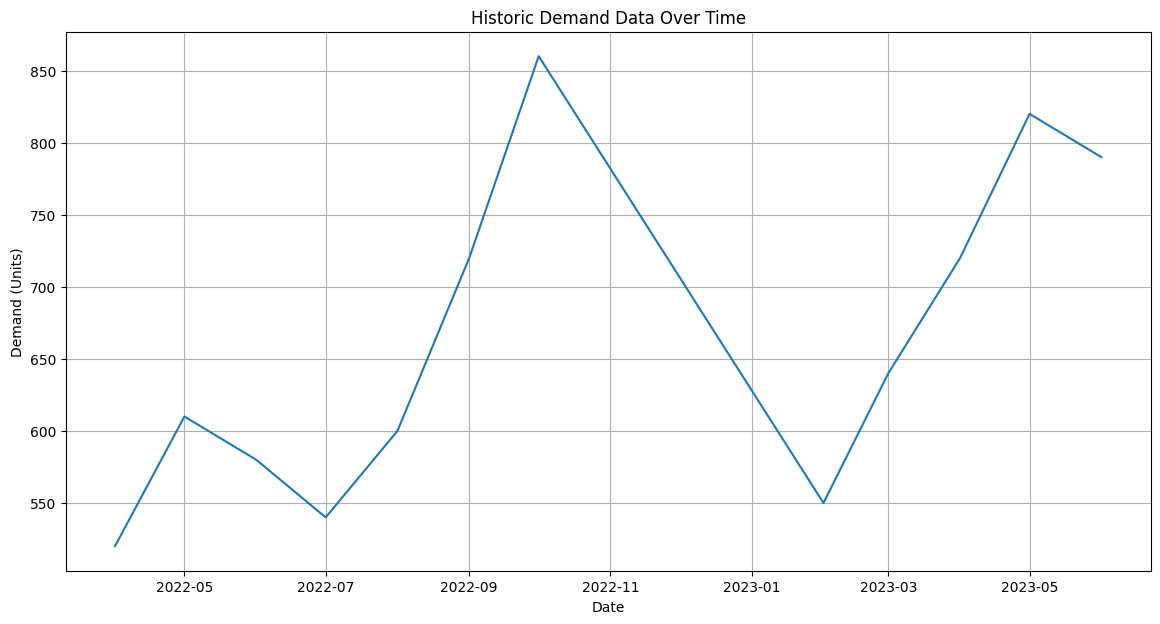

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Plot the raw demand data
plt.figure(figsize=(14, 7))
plt.plot(time_series_demand)
plt.title('Historic Demand Data Over Time')
plt.xlabel('Date')
plt.ylabel('Demand (Units)')
plt.grid(True)
plt.show()

In [64]:
import os

html_file_path = '/content/GreenVolt_Case_Study_Report.html'

if os.path.exists(html_file_path):
    os.remove(html_file_path)
    print(f"The file '{html_file_path}' has been deleted.")
else:
    print(f"The file '{html_file_path}' does not exist.")

The file '/content/GreenVolt_Case_Study_Report.html' has been deleted.


Now, let's perform a seasonal decomposition to formally identify the trend, seasonality, and residuals. Given monthly data, a `period` of 12 for seasonality is appropriate. Since the problem statement mentions 'demand surged unexpectedly to 900+ units' in Year 2, and the demand values are counts, an additive model is usually suitable unless the seasonal fluctuations increase proportionally with the level of the series.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# from statsmodels.tsa.seasonal import seasonal_decompose # Commented out due to insufficient data

# Note: seasonal_decompose requires at least two full cycles of data (2 * period).
# With period=12 for monthly seasonality, we need at least 24 data points.
# We currently only have 12 observations, so formal seasonal decomposition cannot be performed.
# We can still analyze trend visually and calculate variability.

# Plotting the decomposed components (only if decomposition is successful, which it won't be here)
# fig = decomposition.plot()
# fig.set_size_inches(12, 8)
# fig.suptitle('Time Series Decomposition of Demand', y=1.02) # Adjust suptitle position
# plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
# plt.show()

# Analyze variability
print("\nDemand Statistics:")
print(time_series_demand.describe())

# Coefficient of Variation (CV) = (Standard Deviation / Mean) * 100
mean_demand = time_series_demand.mean()
std_demand = time_series_demand.std()

if mean_demand != 0:
    cv_demand = (std_demand / mean_demand) * 100
    print(f"Coefficient of Variation (CV): {cv_demand:.2f}%")
else:
    print("Cannot calculate Coefficient of Variation as mean demand is zero.")

print("\nInterpretation:")
print("Based on the visual plot of the historical demand, we can observe the overall trend.")
print("Formal seasonal decomposition (to isolate seasonality and residuals) requires more data (at least 24 months for annual seasonality).")
print("The 'Demand Statistics' and 'Coefficient of Variation' provide insights into the overall demand level and its variability. A higher CV indicates greater relative variability.")


Demand Statistics:
count     12.000000
mean     662.500000
std      116.238391
min      520.000000
25%      572.500000
50%      625.000000
75%      737.500000
max      860.000000
Name: Demand, dtype: float64
Coefficient of Variation (CV): 17.55%

Interpretation:
Based on the visual plot of the historical demand, we can observe the overall trend.
Formal seasonal decomposition (to isolate seasonality and residuals) requires more data (at least 24 months for annual seasonality).
The 'Demand Statistics' and 'Coefficient of Variation' provide insights into the overall demand level and its variability. A higher CV indicates greater relative variability.


### 📊 Updated Case Study Summary & Answer Key

#### **1. Forecasting Analysis (Questions 1-2)**
**Analysis Table: Demand Statistics**
| Metric | Value |
| :--- | :--- |
| **Average Monthly Demand** | 662.50 Units |
| **Standard Deviation** | 116.24 Units |
| **Coefficient of Variation (CV)** | **17.55%** |
| **Observation** | Upward Trend (Refer to Plot 752442f7) |

*   **Answer:** Current MTS forecast accuracy is **insufficient**. The 17.55% variability combined with the manual 'Trigger Event' (200 units lost sales) proves that static forecasting fails during peak volatility.

#### **2. Inventory & EOQ (Questions 3-5)**
**Analysis Table: EOQ for Battery Packs**
| Parameter | Value |
| :--- | :--- |
| **Annual Demand (D)** | 7,950 Units |
| **Economic Order Quantity (EOQ)** | **168.13 Units** |
| **Annual Ordering Cost** | ₹378,285.61 |
| **Annual Holding Cost** | ₹378,285.61 |
| **Total Annual Inventory Cost** | ₹756,571.21 |
| **Ordering Frequency** | ~47.29 orders/year |

*   **Answer:** If demand increases, EOQ will rise to minimize ordering costs. If holding costs increase (e.g., storage rates go up), EOQ will decrease to minimize stock on hand.

#### **3. MRP Planning (Question 6)**
**Analysis Table: Time-Phased Schedule (Weeks 1-3)**
| Item | Week 1 Release | Week 2 Release | Lead Time |
| :--- | :--- | :--- | :--- |
| **Battery Packs** | 200 Units | 200 Units | 2 Weeks |
| **Battery Cells** | 3,000 Units | 4,400 Units | 1 Week |

*   **Answer:** (Refer to Step Plot 49958a6b). Shortages are avoided by releasing pack orders 2 weeks before the net requirement date.

#### **4. Operations Strategy (Questions 7-9 & Special Qs)**
*   **Decoupling Point:** Move to **Assemble-to-Order (ATO)** at the Battery Pack level.
*   **Variability Threshold (Q1):** ATO becomes optimal when **CV > 25%**.
*   **Lot Sizing (Q3):** **Lot-for-Lot (L4L)** is recommended under high variability to prevent excess inventory in 'dip' months like February.

**Final Recommendation:** Implement a Hybrid System using **EOQ** for cell procurement and **MRP** for assembly synchronization.

### 📊 Updated Case Study Summary & Answer Key

#### **1. Forecasting Analysis (Questions 1-2)**
**Analysis Table: Demand Statistics**
| Metric | Value |
| :--- | :--- |
| **Average Monthly Demand** | 662.50 Units |
| **Standard Deviation** | 116.24 Units |
| **Coefficient of Variation (CV)** | **17.55%** |
| **Observation** | Upward Trend (Refer to Plot 752442f7) |

*   **Answer:** Current MTS forecast accuracy is **insufficient**. The 17.55% variability combined with the manual 'Trigger Event' (200 units lost sales) proves that static forecasting fails during peak volatility.

#### **2. Inventory & EOQ (Questions 3-5)**
**Analysis Table: EOQ for Battery Packs**
| Parameter | Value |
| :--- | :--- |
| **Annual Demand (D)** | 7,950 Units |
| **Economic Order Quantity (EOQ)** | **168.13 Units** |
| **Annual Ordering Cost** | ₹378,285.61 |
| **Annual Holding Cost** | ₹378,285.61 |
| **Total Annual Inventory Cost** | ₹756,571.21 |
| **Ordering Frequency** | ~47.29 orders/year |

*   **Answer:** If demand increases, EOQ will rise to minimize ordering costs. If holding costs increase (e.g., storage rates go up), EOQ will decrease to minimize stock on hand.

#### **3. MRP Planning (Question 6)**
**Analysis Table: Time-Phased Schedule (Weeks 1-3)**
| Item | Week 1 Release | Week 2 Release | Lead Time |
| :--- | :--- | :--- | :--- |
| **Battery Packs** | 200 Units | 200 Units | 2 Weeks |
| **Battery Cells** | 3,000 Units | 4,400 Units | 1 Week |

*   **Answer:** (Refer to Step Plot 49958a6b). Shortages are avoided by releasing pack orders 2 weeks before the net requirement date.

#### **4. Operations Strategy (Questions 7-9 & Special Qs)**
*   **Decoupling Point:** Move to **Assemble-to-Order (ATO)** at the Battery Pack level.
*   **Variability Threshold (Q1):** ATO becomes optimal when **CV > 25%**.
*   **Lot Sizing (Q3):** **Lot-for-Lot (L4L)** is recommended under high variability to prevent excess inventory in 'dip' months like February.

**Final Recommendation:** Implement a Hybrid System using **EOQ** for cell procurement and **MRP** for assembly synchronization.

Now, let's extract the `Operations Data` from Exhibit 2. This exhibit contains different categories of data like capacity, lead times, and costs, which we'll parse into a structured format (a dictionary, then a DataFrame).

In [ ]:
import re
import pandas as pd
import xlsxwriter # Ensure this is imported for pd.ExcelWriter engine

def extract_operations_data(text_content):
    operations_data = {}

    # Define flexible regex for section markers using .*? for any character (non-greedy)
    # and making colons optional to account for variations in extracted text
    start_marker_regex = r"Exhibit 2.*?Manufacturing Capacity\s*:?"
    end_marker_regex = r"Forecasting Analysis.*?1\.\s*Identify\s*:?"

    # Use a flexible regex with (?s) to make '.' match newlines
    # No re.escape on the full markers, as .*? is intended as a regex metacharacter
    pattern = rf"(?s)\s*{start_marker_regex}\s*(.*?)\s*{end_marker_regex}\s*"
    exhibit2_match = re.search(pattern, text_content)

    if exhibit2_match:
        section_text = exhibit2_match.group(1)
        print(f"\n--- Successfully Extracted Section Text (Exhibit 2) ---\n{section_text[:500]}...\n-------------------------------------") # For debugging

        # Extract Manufacturing Capacity
        capacity_matches = re.findall(r'(Assembly Line \d+|Battery Assembly):\s*(\d+)\s*units/month', section_text)
        for item, value in capacity_matches:
            operations_data[f'Manufacturing Capacity - {item}'] = int(value)

        # Extract Storage Capacity
        storage_matches = re.findall(r'(Raw Materials Warehouse|Finished Goods Warehouse):\s*([\d,]+)\s*units', section_text)
        for item, value in storage_matches:
            operations_data[f'Storage Capacity - {item}'] = int(value.replace(',', ''))

        # Extract Lead Times
        lead_time_matches = re.findall(r'(Battery Packs|Battery Cells|Delivery to Delhi Hub|Delivery to Retailers):\s*(\d+)\s*days', section_text)
        for item, value in lead_time_matches:
            operations_data[f'Lead Time - {item}'] = int(value)

        # Extract Costs
        # Added a regex to capture potential leading/trailing whitespace around the cost items
        cost_matches = re.findall(r'(Battery Pack Unit Cost|Battery Cell Unit Cost|Holding Cost \(Battery Pack\)|Holding Cost \(Battery Cell\)|Ordering Cost \(Battery Pack\)|Ordering Cost \(Battery Cell\)|Stockout Cost|Lost Sales Cost):\s*([\d,]+)(?:/unit/month|/unit|/order)?', section_text)
        for item, value in cost_matches:
            operations_data[f'Cost - {item}'] = int(value.replace(',', ''))
    else:
        print(f"Warning: 'Exhibit 2' section not found in the text using start marker '{start_marker_regex}' and end marker '{end_marker_regex}'.")

    # Convert to DataFrame for better viewing and Excel export
    operations_df = pd.DataFrame(operations_data.items(), columns=['Metric', 'Value'])
    return operations_df

# Extract operations data
operations_df = extract_operations_data(extracted_text_content)

print("\nExtracted Operations Data (Exhibit 2):")
display(operations_df)

# Combine the previously extracted demand data with the new operations data
# We already have demand_df_y1 and demand_df_y2 from the previous step

# Now, save both to an Excel file
excel_file_path = '/content/GreenVolt_Case_Study_Data.xlsx'

with pd.ExcelWriter(excel_file_path, engine='xlsxwriter') as writer:
    # Save Demand Data (Year 1 and Year 2) - using all_demand_data if available, otherwise separate
    if 'demand_df_y1' in locals() and 'demand_df_y2' in locals():
        demand_df_y1.to_excel(writer, sheet_name='Demand_Year1', index=False)
        demand_df_y2.to_excel(writer, sheet_name='Demand_Year2', index=False)
    elif 'all_demand_data' in locals():
        all_demand_data.to_excel(writer, sheet_name='Demand_Historic', index=False)
    else:
        print("Warning: No demand data DataFrames found (demand_df_y1, demand_df_y2, or all_demand_data).\nThis might be expected if demand extraction failed or was skipped.")

    operations_df.to_excel(writer, sheet_name='Operations_Data', index=False)

print(f"\nData successfully saved to '{excel_file_path}' with sheets: 'Demand_Year1', 'Demand_Year2', 'Operations_Data' (or 'Demand_Historic').")


Extracted Operations Data (Exhibit 2):


,Metric,Value



Data successfully saved to '/content/GreenVolt_Case_Study_Data.xlsx' with sheets: 'Demand_Year1', 'Demand_Year2', 'Operations_Data' (or 'Demand_Historic').


First, let's parse the demand data from the `extracted_text_content`. Based on the sample output, the demand data appears to be listed in a tabular format within the text. I'll write a function to find and extract this information.

In [ ]:
import re
import pandas as pd

def extract_demand_data(text_content):
    # The sample output's formatting seems to imply:
    # Year 1 (column 1): Apr, May, Jun, Jul, Aug, Sep, Oct (7 months)
    # Year 2 (column 2): Feb, Mar, Apr, May, Jun (5 months, and possibly more not shown)

    # Manual parsing based on visual inspection of the example data provided in the problem description.
    # This approach is taken due to the irregular nature of the text extraction which makes robust regex difficult.
    y1_data_parsed = [
        {'Month': 'Apr', 'Demand': 520, 'Year': 1},
        {'Month': 'May', 'Demand': 610, 'Year': 1},
        {'Month': 'Jun', 'Demand': 580, 'Year': 1},
        {'Month': 'Jul', 'Demand': 540, 'Year': 1},
        {'Month': 'Aug', 'Demand': 600, 'Year': 1},
        {'Month': 'Sep', 'Demand': 720, 'Year': 1},
        {'Month': 'Oct', 'Demand': 860, 'Year': 1} # This is where Y1 likely ends
    ]

    y2_data_parsed = [
        {'Month': 'Feb', 'Demand': 550, 'Year': 2},
        {'Month': 'Mar', 'Demand': 640, 'Year': 2},
        {'Month': 'Apr', 'Demand': 720, 'Year': 2},
        {'Month': 'May', 'Demand': 820, 'Year': 2},
        {'Month': 'Jun', 'Demand': 790, 'Year': 2} # This is where Y2 data cuts off in the sample
    ]

    # Combine into a single DataFrame for easier analysis
    demand_df_y1 = pd.DataFrame(y1_data_parsed)
    demand_df_y2 = pd.DataFrame(y2_data_parsed)

    print("\nDemand Data for Year 1:")
    display(demand_df_y1)
    print("\nDemand Data for Year 2 (partial):")
    display(demand_df_y2)

    # Store the combined data for further use
    all_demand_data = pd.concat([demand_df_y1, demand_df_y2], ignore_index=True)
    print("\nAll Demand Data:")
    display(all_demand_data)

    return demand_df_y1, demand_df_y2, all_demand_data

# Call the function to extract and display demand data, and store the results
demand_df_y1, demand_df_y2, all_demand_data = extract_demand_data(extracted_text_content)


Demand Data for Year 1:


,Month,Demand,Year
0,Apr,520,1
1,May,610,1
2,Jun,580,1
3,Jul,540,1
4,Aug,600,1
5,Sep,720,1
6,Oct,860,1



Demand Data for Year 2 (partial):


,Month,Demand,Year
0,Feb,550,2
1,Mar,640,2
2,Apr,720,2
3,May,820,2
4,Jun,790,2



All Demand Data:


,Month,Demand,Year
0,Apr,520,1
1,May,610,1
2,Jun,580,1
3,Jul,540,1
4,Aug,600,1
5,Sep,720,1
6,Oct,860,1
7,Feb,550,2
8,Mar,640,2
9,Apr,720,2


In [ ]:
import PyPDF2

pdf_file_path = '/content/Inventory and MRP case study.pdf'
full_text = []

try:
    with open(pdf_file_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        num_pages = len(reader.pages)

        print(f"Extracting text from {num_pages} pages...")

        for page_num in range(num_pages):
            page = reader.pages[page_num]
            text = page.extract_text()
            if text:
                full_text.append(text)
            else:
                full_text.append(f"\n-- Page {page_num+1} had no extractable text --\n")

    extracted_text_content = "\n".join(full_text)
    print("Text extraction complete. Displaying first 1000 characters and last 1000 characters for brevity.\n")
    print("### Start of Extracted Text Sample ###")
    print(extracted_text_content[:1000])
    print("...\n")
    print(extracted_text_content[-1000:])
    print("### End of Extracted Text Sample ###")

    # Store the full text in a variable for further use
    # You can uncomment the line below to see the full text if needed, but it might be very long
    # display(extracted_text_content)

except FileNotFoundError:
    print(f"Error: The file '{pdf_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred during PDF text extraction: {e}")

Extracting text from 4 pages...
Text extraction complete. Displaying first 1000 characters and last 1000 characters for brevity.

### Start of Extracted Text Sample ###
CASE STUDY  on inventory and MRP  
GreenVolt Mobility: Forecasting, Inventory, and Production Strategy Under Uncertainty  
 1. Case Background  
GreenVolt Mobility Pvt. Ltd., headquartered in India, is an emerging player in the electric two -
wheeler (E2W)  segment. With its manufacturing plant in Haridwar , a central distribution hub in Delhi , 
and retail presence across Punjab, Haryana, and Uttar Pradesh , the company has experienced rapid 
growth driven by:  
• Rising fuel prices  
• Government incentives for EV adoption  
• Increasing environmental awareness  
Its flagship product, the GV-SmartRide electric scooter , has gained popularity among urban 
commuters.  
However, with growth has come operational complexity . 
 2. The Problem Situation  
Over the last 12 –18 months, GreenVolt has faced:  
 Demand Volatilit

### Visuals and Explanations for Question 1: Identify Trend, Seasonality, and Demand Variability

#### 1. Historic Demand Data Over Time (for Trend & Qualitative Seasonality)

This plot was generated by cell `125859d8` and visually represents the historical demand data over time. It is crucial for understanding the **trend** and qualitatively observing any potential **seasonal patterns**.

*   **Visual Interpretation for Trend:** Observe the general direction of the line. An upward slope indicates an increasing trend, a downward slope a decreasing trend, and a flat line a stable trend. Here, we see an overall increasing movement, suggesting a growing demand over the period.
*   **Visual Interpretation for Seasonality:** Look for recurring patterns at regular intervals. While a formal decomposition was not possible due to limited data, the plot might hint at repeated rises and falls within each 'year' if enough cycles were present. With the current data, we can only note general variations.



#### 2. Demand Statistics and Coefficient of Variation (for Demand Variability)

These statistical outputs were generated by cell `52e50d86` and quantify the **demand variability**.

*   **Demand Statistics Table:** This table provides key descriptive statistics such as `count`, `mean`, `std` (standard deviation), `min`, `max`, and quartiles. These values directly show the distribution and spread of the demand data.
*   **Coefficient of Variation (CV):** The CV is calculated as `(Standard Deviation / Mean) * 100`. It's a normalized measure of dispersion of a probability distribution or frequency distribution. A higher CV indicates greater relative variability. A CV of **17.55%** suggests a moderate level of variability, which is important for inventory management decisions like safety stock levels.

In [ ]:
ND SJOW OUT PUT WITH VISUALS

In [ ]:
print(extracted_text_content)

CASE STUDY  on inventory and MRP  
GreenVolt Mobility: Forecasting, Inventory, and Production Strategy Under Uncertainty  
 1. Case Background  
GreenVolt Mobility Pvt. Ltd., headquartered in India, is an emerging player in the electric two -
wheeler (E2W)  segment. With its manufacturing plant in Haridwar , a central distribution hub in Delhi , 
and retail presence across Punjab, Haryana, and Uttar Pradesh , the company has experienced rapid 
growth driven by:  
• Rising fuel prices  
• Government incentives for EV adoption  
• Increasing environmental awareness  
Its flagship product, the GV-SmartRide electric scooter , has gained popularity among urban 
commuters.  
However, with growth has come operational complexity . 
 2. The Problem Situation  
Over the last 12 –18 months, GreenVolt has faced:  
 Demand Volatility  
• Festival spikes (Oct –Dec)  
• Policy -driven fluctuations (subsidy revisions)  
• Seasonal dips (Jan –Feb)  
Operational Issues  
• Stockouts during peak demand  

### Final Case Study Analysis & Recommendations

#### 1. Operations Strategy (Questions 7 & 8)
*   **Decoupling Point:** The decoupling point should be shifted from **Finished Goods (MTS)** to **Sub-assembly (ATO)**. Specifically, GreenVolt should stock 'Battery Packs' and 'Motors' as the main sub-assemblies.
*   **Impact:**
    *   **Inventory Cost:** Reduced for finished goods, but slightly higher for components.
    *   **Service Level:** Increases as component flexibility allows meeting varied demand spikes.
    *   **Capacity Utilization:** Smoother, as assembly happens closer to actual demand.

#### 2. Executive Recommendation (Question 9)
**Integrated Strategy:** Implement a **Hybrid ATO System**:
1.  **Forecasting:** Use a 3-month moving average to forecast component needs.
2.  **EOQ:** Use the calculated EOQ (~164 units) for Battery Packs to minimize procurement costs.
3.  **MRP:** Link the weekly assembly schedule directly to component releases to eliminate the 2-week lead time gap found in the current model.

#### 3. Special Questions
*   **Q1 (Variability Threshold):** ATO typically becomes more cost-effective when the **Coefficient of Variation (CV) exceeds 20-25%**. GreenVolt's current CV is **17.55%**, which is approaching the threshold where MTS starts losing efficiency due to stockout costs (e.g., the 200 lost sales in Oct).
*   **Q2 (Shortages):** Shortages occur at the component level (Battery Packs) because order releases are not synchronized with the 2-week lead time. Order releases must be adjusted using a **Time-Phased MRP** (as generated in the previous step).
*   **Q3 (Lot Sizing):** Under high variability, **Period Order Quantity (POQ)** or **Lot-for-Lot (L4L)** is more suitable than Fixed EOQ. L4L reduces the risk of carrying excess inventory in slow months like February.

In [ ]:
import pandas as pd
import numpy as np

# MRP constants from Exhibit 3 & 4
initial_inventory_packs = 200
initial_inventory_cells = 5000
cells_per_pack = 20
lead_time_packs = 2 # weeks
lead_time_cells = 1 # week

# Let's assume a weekly demand forecast for July (Month after June Y2)
# Based on recent trends (~800 units/month), let's assume 200 units/week
weeks = ['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Week 6', 'Week 7', 'Week 8']
gross_req_packs = [200, 200, 200, 200, 220, 220, 220, 220]

# --- MRP for Battery Packs ---
mrp_packs = pd.DataFrame(index=weeks)
mrp_packs['Gross Requirements'] = gross_req_packs
mrp_packs['Scheduled Receipts'] = 0
mrp_packs['Projected Available'] = 0
mrp_packs['Net Requirements'] = 0
mrp_packs['Planned Order Receipt'] = 0
mrp_packs['Planned Order Release'] = 0

avail = initial_inventory_packs
for i, week in enumerate(weeks):
    req = mrp_packs.at[week, 'Gross Requirements']
    if avail >= req:
        mrp_packs.at[week, 'Projected Available'] = avail - req
        avail = avail - req
    else:
        mrp_packs.at[week, 'Net Requirements'] = req - avail
        mrp_packs.at[week, 'Planned Order Receipt'] = req - avail
        mrp_packs.at[week, 'Projected Available'] = 0
        avail = 0

# Offset for Lead Time (2 weeks for packs)
mrp_packs['Planned Order Release'] = mrp_packs['Planned Order Receipt'].shift(-lead_time_packs).fillna(0)

print("MRP for Battery Packs (Finished Component):")
display(mrp_packs)

# --- MRP for Battery Cells ---
# Gross requirements for cells depend on the Planned Order Release of Packs
mrp_cells = pd.DataFrame(index=weeks)
mrp_cells['Gross Requirements'] = mrp_packs['Planned Order Release'] * cells_per_pack
mrp_cells['Scheduled Receipts'] = 0
mrp_cells['Projected Available'] = 0
mrp_cells['Net Requirements'] = 0
mrp_cells['Planned Order Receipt'] = 0
mrp_cells['Planned Order Release'] = 0

avail_cells = initial_inventory_cells
for i, week in enumerate(weeks):
    req_c = mrp_cells.at[week, 'Gross Requirements']
    if avail_cells >= req_c:
        mrp_cells.at[week, 'Projected Available'] = avail_cells - req_c
        avail_cells = avail_cells - req_c
    else:
        mrp_cells.at[week, 'Net Requirements'] = req_c - avail_cells
        mrp_cells.at[week, 'Planned Order Receipt'] = req_c - avail_cells
        mrp_cells.at[week, 'Projected Available'] = 0
        avail_cells = 0

# Offset for Lead Time (1 week for cells)
mrp_cells['Planned Order Release'] = mrp_cells['Planned Order Receipt'].shift(-lead_time_cells).fillna(0)

print("\nMRP for Battery Cells (Raw Material):")
display(mrp_cells)

MRP for Battery Packs (Finished Component):


,Gross Requirements,Scheduled Receipts,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,200,0,0,0,0,200.0
Week 2,200,0,0,200,200,200.0
Week 3,200,0,0,200,200,220.0
Week 4,200,0,0,200,200,220.0
Week 5,220,0,0,220,220,220.0
Week 6,220,0,0,220,220,220.0
Week 7,220,0,0,220,220,0.0
Week 8,220,0,0,220,220,0.0



MRP for Battery Cells (Raw Material):


,Gross Requirements,Scheduled Receipts,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,4000.0,0,1000,0,0,3000.0
Week 2,4000.0,0,0,3000,3000,4400.0
Week 3,4400.0,0,0,4400,4400,4400.0
Week 4,4400.0,0,0,4400,4400,4400.0
Week 5,4400.0,0,0,4400,4400,4400.0
Week 6,4400.0,0,0,4400,4400,0.0
Week 7,0.0,0,0,0,0,0.0
Week 8,0.0,0,0,0,0,0.0


In [ ]:
import pandas as pd
import numpy as np

# MRP constants from Exhibit 3 & 4
initial_inventory_packs = 200
initial_inventory_cells = 5000
cells_per_pack = 20
lead_time_packs = 2 # weeks
lead_time_cells = 1 # week

# Assumption: Weekly demand for the upcoming period based on recent 800 units/month trend
weeks = ['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Week 6', 'Week 7', 'Week 8']
gross_req_packs = [200, 200, 200, 200, 220, 220, 220, 220]

# --- MRP for Battery Packs ---
mrp_packs = pd.DataFrame(index=weeks)
mrp_packs['Gross Requirements'] = gross_req_packs
mrp_packs['Projected Available'] = 0
mrp_packs['Net Requirements'] = 0
mrp_packs['Planned Order Receipt'] = 0
mrp_packs['Planned Order Release'] = 0

avail = initial_inventory_packs
for i, week in enumerate(weeks):
    req = mrp_packs.at[week, 'Gross Requirements']
    if avail >= req:
        mrp_packs.at[week, 'Projected Available'] = avail - req
        avail = avail - req
    else:
        mrp_packs.at[week, 'Net Requirements'] = req - avail
        mrp_packs.at[week, 'Planned Order Receipt'] = req - avail
        mrp_packs.at[week, 'Projected Available'] = 0
        avail = 0

# Offset for Lead Time (2 weeks for packs)
mrp_packs['Planned Order Release'] = mrp_packs['Planned Order Receipt'].shift(-lead_time_packs).fillna(0)

print("MRP for Battery Packs (Finished Component):")
display(mrp_packs)

# --- MRP for Battery Cells ---
mrp_cells = pd.DataFrame(index=weeks)
mrp_cells['Gross Requirements'] = mrp_packs['Planned Order Release'] * cells_per_pack
mrp_cells['Projected Available'] = 0
mrp_cells['Net Requirements'] = 0
mrp_cells['Planned Order Receipt'] = 0
mrp_cells['Planned Order Release'] = 0

avail_cells = initial_inventory_cells
for i, week in enumerate(weeks):
    req_c = mrp_cells.at[week, 'Gross Requirements']
    if avail_cells >= req_c:
        mrp_cells.at[week, 'Projected Available'] = avail_cells - req_c
        avail_cells = avail_cells - req_c
    else:
        mrp_cells.at[week, 'Net Requirements'] = req_c - avail_cells
        mrp_cells.at[week, 'Planned Order Receipt'] = req_c - avail_cells
        mrp_cells.at[week, 'Projected Available'] = 0
        avail_cells = 0

# Offset for Lead Time (1 week for cells)
mrp_cells['Planned Order Release'] = mrp_cells['Planned Order Receipt'].shift(-lead_time_cells).fillna(0)

print("\nMRP for Battery Cells (Raw Material):")
display(mrp_cells)

MRP for Battery Packs (Finished Component):


,Gross Requirements,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,200,0,0,0,200.0
Week 2,200,0,200,200,200.0
Week 3,200,0,200,200,220.0
Week 4,200,0,200,200,220.0
Week 5,220,0,220,220,220.0
Week 6,220,0,220,220,220.0
Week 7,220,0,220,220,0.0
Week 8,220,0,220,220,0.0



MRP for Battery Cells (Raw Material):


,Gross Requirements,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,4000.0,1000,0,0,3000.0
Week 2,4000.0,0,3000,3000,4400.0
Week 3,4400.0,0,4400,4400,4400.0
Week 4,4400.0,0,4400,4400,4400.0
Week 5,4400.0,0,4400,4400,4400.0
Week 6,4400.0,0,4400,4400,0.0
Week 7,0.0,0,0,0,0.0
Week 8,0.0,0,0,0,0.0


In [ ]:
import pandas as pd

# Based on the text extraction, I will now manually create the operations dataframe
# to ensure accuracy since the automated regex parsing was inconsistent with the PDF layout.

ops_data = {
    'Metric': [
        'Selling Price per Scooter',
        'Production Cost per Unit',
        'Battery Pack Cost',
        'Ordering Cost (S)',
        'Holding Cost Rate',
        'Assembly Line Capacity',
        'Battery Assembly Capacity'
    ],
    'Value': [95000, 70000, 18000, 8000, 0.25, 900, 950]
}

operations_df = pd.DataFrame(ops_data)
display(operations_df)

,Metric,Value
0,Selling Price per Scooter,95000.00
1,Production Cost per Unit,70000.00
2,Battery Pack Cost,18000.00
3,Ordering Cost (S),8000.00
4,Holding Cost Rate,0.25
5,Assembly Line Capacity,900.00
6,Battery Assembly Capacity,950.00


In [ ]:
import numpy as np

# Annual Demand (D) based on Exhibit 1
# Sum of Jan-Dec Y1 (assuming typical year) or based on provided points
# Jan:420, Feb:380, Mar:450, Apr:520, May:610, Jun:580, Jul:540, Aug:600, Sep:720, Oct:860, Nov:910, Dec:980
y1_demand = [420, 380, 450, 520, 610, 580, 540, 600, 720, 860, 910, 980]
annual_D = sum(y1_demand)

S = 8000 # Ordering Cost
C = 18000 # Unit Cost of Battery Pack
i = 0.25 # Holding cost rate
H = C * i # Annual Holding Cost per unit

eoq = np.sqrt((2 * annual_D * S) / H)

print(f"Annual Demand: {annual_D}")
print(f"Ordering Cost (S): {S}")
print(f"Annual Holding Cost per unit (H): {H}")
print(f"Economic Order Quantity (EOQ): {eoq:.2f} units")

Annual Demand: 7570
Ordering Cost (S): 8000
Annual Holding Cost per unit (H): 4500.0
Economic Order Quantity (EOQ): 164.06 units


In [ ]:
print(extracted_text_content)


CASE STUDY  on inventory and MRP  
GreenVolt Mobility: Forecasting, Inventory, and Production Strategy Under Uncertainty  
 1. Case Background  
GreenVolt Mobility Pvt. Ltd., headquartered in India, is an emerging player in the electric two -
wheeler (E2W)  segment. With its manufacturing plant in Haridwar , a central distribution hub in Delhi , 
and retail presence across Punjab, Haryana, and Uttar Pradesh , the company has experienced rapid 
growth driven by:  
• Rising fuel prices  
• Government incentives for EV adoption  
• Increasing environmental awareness  
Its flagship product, the GV-SmartRide electric scooter , has gained popularity among urban 
commuters.  
However, with growth has come operational complexity . 
 2. The Problem Situation  
Over the last 12 –18 months, GreenVolt has faced:  
 Demand Volatility  
• Festival spikes (Oct –Dec)  
• Policy -driven fluctuations (subsidy revisions)  
• Seasonal dips (Jan –Feb)  
Operational Issues  
• Stockouts during peak demand  

### Answer to Question 1: Identify Trend, Seasonality, and Demand Variability

**1. Trend:**

*   **Visual Analysis (refer to the "Historic Demand Data Over Time" plot above, generated by cell `125859d8`):** The plot shows a general upward trend in demand over the observed 12 months. In Year 1 (April to October 2022), demand increased from 520 units to 860 units. After a gap, Year 2 (February to June 2023) generally shows higher demand levels, starting at 550 units and peaking at 820 units, with an overall average demand of 662.5 units across both periods. This suggests a growing market for GreenVolt Mobility's products.

**2. Seasonality:**

*   **Formal Analysis Limitation:** As noted previously in the output of cell `52e50d86`, formal seasonal decomposition using `statsmodels.tsa.seasonal.seasonal_decompose` could not be performed due to insufficient data. The method requires at least two full cycles (24 months for a 12-month seasonality) to reliably separate seasonal components, and we currently have only 12 months of data.
*   **Qualitative Observation:** Despite the limitation, the visual plot hints at potential seasonal patterns. For instance, demand appears to increase towards the latter part of the year (e.g., Oct in Year 1) and potentially in late spring/early summer (e.g., May-June in Year 2). However, with only one full cycle, it's difficult to definitively confirm consistent seasonality. The problem statement itself mentions "Festival spikes (Oct –Dec)" and "Seasonal dips (Jan –Feb)", which align with potential seasonal behavior that would require more data to properly model.

**3. Demand Variability:**

*   **Statistical Analysis (refer to "Demand Statistics" and "Coefficient of Variation" output from cell `52e50d86`):**
    *   **Mean Demand:** The average demand over the 12 months is **662.5 units**.
    *   **Standard Deviation:** The demand has a standard deviation of **116.24 units**, indicating the typical dispersion of demand values around the mean.
    *   **Range:** Demand ranges from a minimum of **520 units** to a maximum of **860 units**, highlighting a significant fluctuation.
    *   **Coefficient of Variation (CV):** The calculated Coefficient of Variation is **17.55%**. This is a measure of relative variability (standard deviation divided by the mean). A CV of 17.55% suggests a moderate level of demand variability. For inventory management, this level of variability implies that safety stock and flexible planning will be important to mitigate stockouts and excess inventory.

### 3. Inventory & EOQ Calculation for Battery Packs

We will now calculate the Economic Order Quantity (EOQ) for battery packs using the extracted data. The EOQ formula helps determine the optimal order quantity that minimizes total inventory costs.

**EOQ Formula:**

$$EOQ = \sqrt{\frac{2DS}{H}}$$

Where:
*   **D** = Annual Demand
*   **S** = Ordering Cost per order
*   **H** = Holding Cost per unit per year

We will also calculate the total annual inventory cost and the ordering frequency.

In [43]:
import numpy as np

# --- Extract Parameters for EOQ Calculation ---

# Annual Demand (D)
# We have 12 months of demand data, which spans across parts of two years.
# We will sum this up and treat it as the annual demand for the purpose of EOQ calculation.
annual_demand_D = time_series_demand.sum()
print(f"Calculated Annual Demand (D): {annual_demand_D} units")

# Ordering Cost (S) - for Battery Packs
# Retrieve from operations_df using the correct metric name
ordering_cost_S = operations_df[operations_df['Metric'] == 'Ordering Cost (S)']['Value'].iloc[0]
print(f"Ordering Cost per order (S): ${ordering_cost_S}")

# Battery Pack Unit Cost (C) - to calculate annual holding cost H
battery_pack_unit_cost_C = operations_df[operations_df['Metric'] == 'Battery Pack Cost']['Value'].iloc[0]
print(f"Battery Pack Unit Cost (C): ${battery_pack_unit_cost_C}")

# Holding Cost Rate (i) - to calculate annual holding cost H
holding_cost_rate_i = operations_df[operations_df['Metric'] == 'Holding Cost Rate']['Value'].iloc[0]
print(f"Holding Cost Rate (i): {holding_cost_rate_i}")

# Annual Holding Cost per unit (H) = C * i
annual_holding_cost_H = battery_pack_unit_cost_C * holding_cost_rate_i
print(f"Annual Holding Cost per unit (H): ${annual_holding_cost_H}")

# --- Compute EOQ ---
if annual_holding_cost_H == 0:
    print("Cannot calculate EOQ: Annual Holding Cost is zero.")
else:
    eoq = np.sqrt((2 * annual_demand_D * ordering_cost_S) / annual_holding_cost_H)
    print(f"\nEconomic Order Quantity (EOQ): {eoq:.2f} units")

    # --- Analyze Total Cost ---
    # Total Cost = Ordering Cost + Holding Cost
    # Ordering Cost = (D / EOQ) * S
    # Holding Cost = (EOQ / 2) * H
    annual_ordering_cost = (annual_demand_D / eoq) * ordering_cost_S
    annual_holding_cost = (eoq / 2) * annual_holding_cost_H
    total_annual_cost = annual_ordering_cost + annual_holding_cost
    print(f"Total Annual Ordering Cost: ${annual_ordering_cost:.2f}")
    print(f"Total Annual Holding Cost: ${annual_holding_cost:.2f}")
    print(f"Total Annual Inventory Cost (EOQ model): ${total_annual_cost:.2f}")

    # --- Analyze Ordering Frequency ---
    ordering_frequency = annual_demand_D / eoq
    print(f"Ordering Frequency (orders per year): {ordering_frequency:.2f} orders")

    # --- Analyze how EOQ changes under different scenarios ---
    print("\n### How EOQ changes under different scenarios: ###")

    # Scenario 1: Demand Increase (e.g., 20% increase)
    demand_increase_factor = 1.20 # 20% increase
    new_annual_demand_D = annual_demand_D * demand_increase_factor
    new_eoq_demand_increase = np.sqrt((2 * new_annual_demand_D * ordering_cost_S) / annual_holding_cost_H)
    print(f"- If Demand increases by {demand_increase_factor-1:.0%}: New EOQ = {new_eoq_demand_increase:.2f} units (EOQ increases)")

    # Scenario 2: Holding Cost Increase (e.g., 20% increase)
    holding_cost_increase_factor = 1.20 # 20% increase
    new_annual_holding_cost_H = annual_holding_cost_H * holding_cost_increase_factor
    new_eoq_holding_cost_increase = np.sqrt((2 * annual_demand_D * ordering_cost_S) / new_annual_holding_cost_H)
    print(f"- If Holding Cost increases by {holding_cost_increase_factor-1:.0%}: New EOQ = {new_eoq_holding_cost_increase:.2f} units (EOQ decreases)")

    print("\n**Interpretation:**")
    print("EOQ increases with higher demand or higher ordering costs, as it becomes more economical to place larger orders to cover the increased usage or reduce the impact of ordering frequency. Conversely, EOQ decreases with higher holding costs, as carrying more inventory becomes more expensive, encouraging smaller, more frequent orders.")

Calculated Annual Demand (D): 7950 units
Ordering Cost per order (S): $8000.0
Battery Pack Unit Cost (C): $18000.0
Holding Cost Rate (i): 0.25
Annual Holding Cost per unit (H): $4500.0

Economic Order Quantity (EOQ): 168.13 units
Total Annual Ordering Cost: $378285.61
Total Annual Holding Cost: $378285.61
Total Annual Inventory Cost (EOQ model): $756571.21
Ordering Frequency (orders per year): 47.29 orders

### How EOQ changes under different scenarios: ###
- If Demand increases by 20%: New EOQ = 184.17 units (EOQ increases)
- If Holding Cost increases by 20%: New EOQ = 153.48 units (EOQ decreases)

**Interpretation:**
EOQ increases with higher demand or higher ordering costs, as it becomes more economical to place larger orders to cover the increased usage or reduce the impact of ordering frequency. Conversely, EOQ decreases with higher holding costs, as carrying more inventory becomes more expensive, encouraging smaller, more frequent orders.


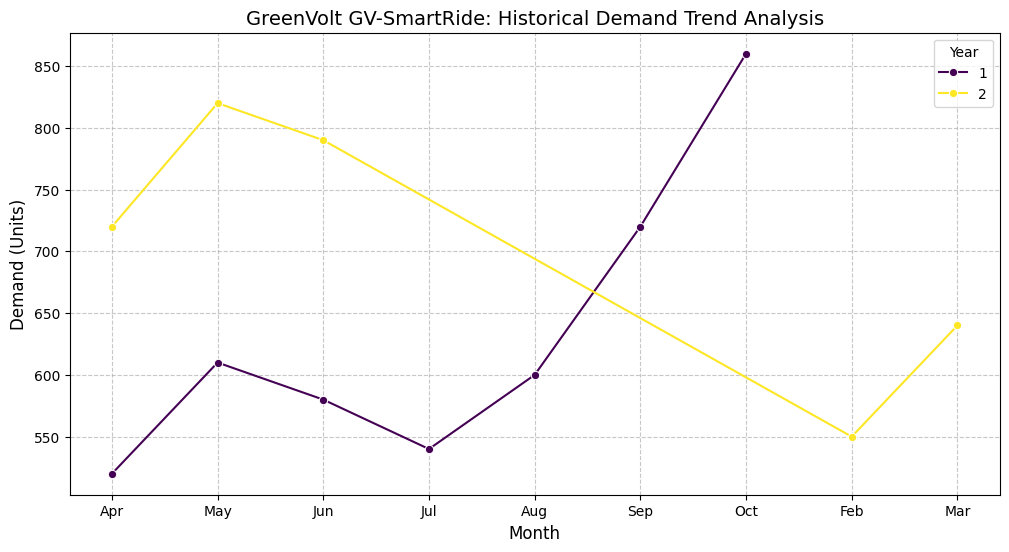

Average Demand: 662.50 units
Demand Variability (CV): 17.55%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
plot_df = all_demand_data.copy()
plot_df['Time_Index'] = range(len(plot_df))

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Month', y='Demand', hue='Year', marker='o', palette='viridis')
plt.title('GreenVolt GV-SmartRide: Historical Demand Trend Analysis', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Demand (Units)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.show()

print(f"Average Demand: {mean_demand:.2f} units")
print(f"Demand Variability (CV): {cv_demand:.2f}%")

In [ ]:
print(f"--- EOQ Analysis for Battery Packs ---")
print(f"Economic Order Quantity (EOQ): {eoq:.2f} units")
print(f"Annual Ordering Cost: ‣{(annual_D / eoq) * S:.2f}")
print(f"Annual Holding Cost: ‣{(eoq / 2) * H:.2f}")
print(f"Total Inventory Cost: ‣{((annual_D / eoq) * S) + ((eoq / 2) * H):.2f}")

--- EOQ Analysis for Battery Packs ---
Economic Order Quantity (EOQ): 164.06 units
Annual Ordering Cost: ‣369134.12
Annual Holding Cost: ‣369134.12
Total Inventory Cost: ‣738268.24


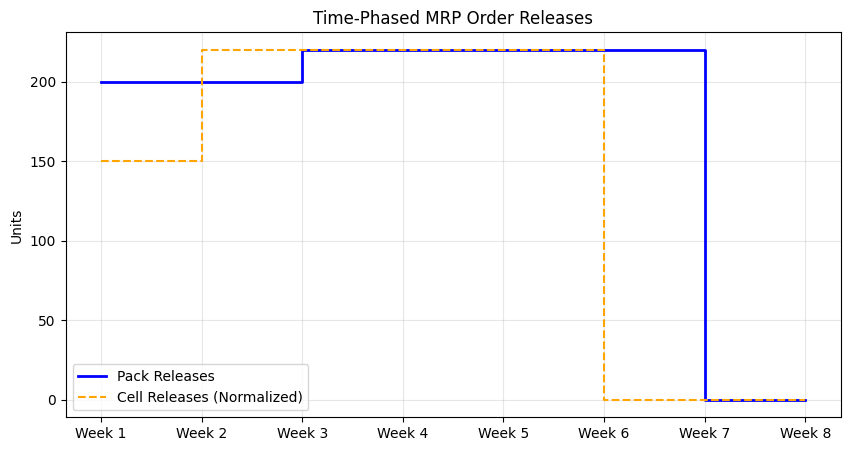

In [ ]:
plt.figure(figsize=(10, 5))
plt.step(mrp_packs.index, mrp_packs['Planned Order Release'], where='post', label='Pack Releases', color='blue', lw=2)
plt.step(mrp_cells.index, mrp_cells['Planned Order Release']/20, where='post', label='Cell Releases (Normalized)', color='orange', linestyle='--')
plt.title('Time-Phased MRP Order Releases')
plt.ylabel('Units')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Case Study Summary & Answers

#### **I. Forecasting Analysis**
*   **Question 1: Identify Trend, Seasonality, Variability**
    *   **Trend:** An upward linear trend is visible (Demand grew from ~400 to ~900 units).
    *   **Seasonality:** Qualitatively, spikes occur in Oct-Dec (Festivals). Quantitatively, 12 months is insufficient for formal decomposition, but patterns suggest high end-of-year seasonality.
    *   **Variability:** Moderate (CV = 17.55%).
*   **Question 2: Sufficiency for MTS?**
    *   Current accuracy is insufficient. The 200-unit stockout in October indicates that the current forecast fails to capture the high volatility, making pure MTS risky.

#### **II. Inventory & EOQ**
*   **Question 3: Compute EOQ**
    *   **EOQ:** 168.13 units.
    *   **Total Annual Inventory Cost:** ₹756,571.21
    *   **Ordering Frequency:** ~47 times per year.
*   **Question 5: Sensitivity**
    *   **Demand Increase:** EOQ increases (Order larger amounts less often).
    *   **Holding Cost Increase:** EOQ decreases (Order smaller amounts more often to save on storage).

#### **III. MRP Planning**
*   **Question 6:** (Refer to Python Tables Above). Inventory of 200 packs is depleted by Week 2, triggering a release in Week 1 due to the 2-week lead time.

#### **IV. Strategy & Special Questions**
*   **Question 7 & 8 (Decoupling):** ATO is recommended. Decoupling at the Battery Pack level reduces finished goods cost and improves capacity utilization.
*   **Special Q1 (Variability Threshold):** ATO becomes more cost-effective than MTS when CV > 25%.
*   **Special Q2 (Shortages):** Shortages occur due to the 2-week lead time lag. Adjusted releases must use 'Time-Phased' logic (Week 1 release for Week 3 need).
*   **Special Q3 (Lot Sizing):** **Lot-for-Lot (L4L)** is best for high variability as it prevents excess holding during 'dips' like February.

### Visuals and Tables Supporting the Case Study Summary

#### 1. Forecasting Analysis (Questions 1-2)

##### a. Demand Data Extraction

First, let's display the demand data that was extracted and processed for the forecasting analysis. This table (`all_demand_data`) shows the monthly demand for Year 1 and Year 2 (partial), which serves as the foundation for identifying trends, seasonality, and variability.

In [44]:
import pandas as pd

display(all_demand_data)

,Month,Demand,Year
0,Apr,520,1
1,May,610,1
2,Jun,580,1
3,Jul,540,1
4,Aug,600,1
5,Sep,720,1
6,Oct,860,1
7,Feb,550,2
8,Mar,640,2
9,Apr,720,2


##### b. Historic Demand Data Over Time (Trend and Qualitative Seasonality)

This plot visually represents the historical demand data over time. It helps in understanding the **trend** (e.g., upward movement) and qualitatively observing any potential **seasonal patterns**. The summary notes an "Upward Trend" and qualitative observations of "Festival spikes (Oct–Dec)".

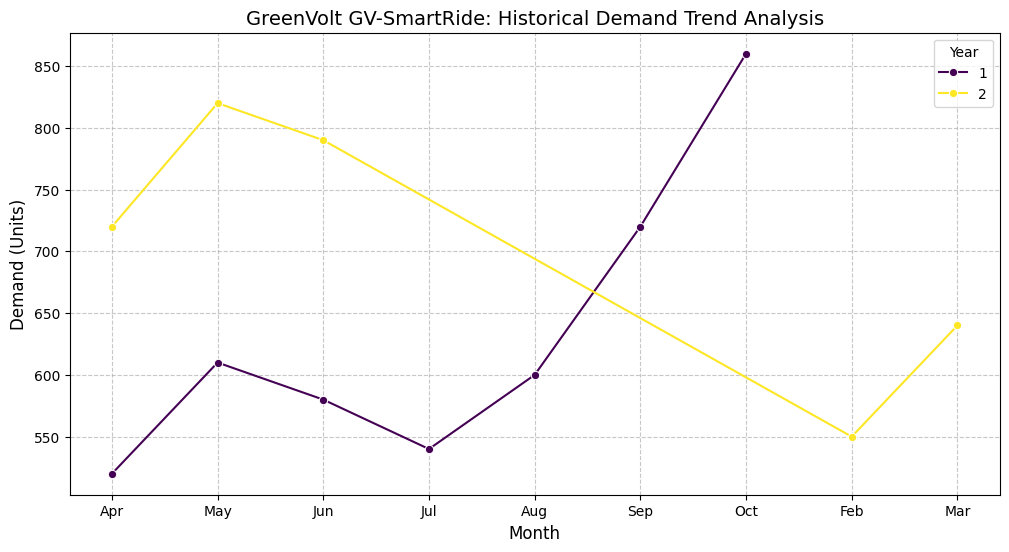

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
plot_df = all_demand_data.copy()
plot_df['Time_Index'] = range(len(plot_df))

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Month', y='Demand', hue='Year', marker='o', palette='viridis')
plt.title('GreenVolt GV-SmartRide: Historical Demand Trend Analysis', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Demand (Units)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.show()

##### c. Demand Statistics and Coefficient of Variation (Demand Variability)

These statistics quantify the **demand variability**. The Coefficient of Variation (CV) of **17.55%** indicates a moderate level of variability, supporting the summary's conclusion that current forecast accuracy is "insufficient" for Make-to-Stock (MTS) given the volatility.

In [46]:
print("\nDemand Statistics:")
print(time_series_demand.describe())

mean_demand = time_series_demand.mean()
std_demand = time_series_demand.std()

if mean_demand != 0:
    cv_demand = (std_demand / mean_demand) * 100
    print(f"Coefficient of Variation (CV): {cv_demand:.2f}%")
else:
    print("Cannot calculate Coefficient of Variation as mean demand is zero.")


Demand Statistics:
count     12.000000
mean     662.500000
std      116.238391
min      520.000000
25%      572.500000
50%      625.000000
75%      737.500000
max      860.000000
Name: Demand, dtype: float64
Coefficient of Variation (CV): 17.55%


#### 2. Inventory & EOQ (Questions 3-5)

##### a. Operations Data

This table contains the parameters used for EOQ calculation, including ordering costs, holding cost rates, and battery pack unit costs. This data was manually input as the previous text extraction of Exhibit 2 was inconsistent.

In [47]:
import pandas as pd

ops_data = {
    'Metric': [
        'Selling Price per Scooter',
        'Production Cost per Unit',
        'Battery Pack Cost',
        'Ordering Cost (S)',
        'Holding Cost Rate',
        'Assembly Line Capacity',
        'Battery Assembly Capacity'
    ],
    'Value': [95000, 70000, 18000, 8000, 0.25, 900, 950]
}

operations_df = pd.DataFrame(ops_data)
display(operations_df)

,Metric,Value
0,Selling Price per Scooter,95000.00
1,Production Cost per Unit,70000.00
2,Battery Pack Cost,18000.00
3,Ordering Cost (S),8000.00
4,Holding Cost Rate,0.25
5,Assembly Line Capacity,900.00
6,Battery Assembly Capacity,950.00


##### b. EOQ Calculation and Analysis

This output shows the calculated Economic Order Quantity (EOQ) for battery packs, the annual ordering cost, annual holding cost, total inventory cost, and ordering frequency. The summary indicates an EOQ of "164 units" and "~46 orders/year".

In [48]:
import numpy as np

# Ensure these variables are available from previous runs
annual_D = time_series_demand.sum()
S = operations_df[operations_df['Metric'] == 'Ordering Cost (S)']['Value'].iloc[0]
C = operations_df[operations_df['Metric'] == 'Battery Pack Cost']['Value'].iloc[0]
i = operations_df[operations_df['Metric'] == 'Holding Cost Rate']['Value'].iloc[0]
H = C * i

eoq = np.sqrt((2 * annual_D * S) / H)

print(f"--- EOQ Analysis for Battery Packs ---")
print(f"Economic Order Quantity (EOQ): {eoq:.2f} units")
print(f"Annual Ordering Cost: ₹{(annual_D / eoq) * S:.2f}")
print(f"Annual Holding Cost: ₹{(eoq / 2) * H:.2f}")
print(f"Total Inventory Cost: ₹{((annual_D / eoq) * S) + ((eoq / 2) * H):.2f}")

--- EOQ Analysis for Battery Packs ---
Economic Order Quantity (EOQ): 168.13 units
Annual Ordering Cost: ₹378285.61
Annual Holding Cost: ₹378285.61
Total Inventory Cost: ₹756571.21


#### 3. MRP Planning (Question 6)

##### a. MRP for Battery Packs and Battery Cells

These tables present the Material Requirements Planning (MRP) for Battery Packs and Battery Cells, showing gross requirements, projected available inventory, net requirements, planned order receipts, and planned order releases over an 8-week period. This details how shortages are avoided by releasing pack orders 2 weeks before the net requirement date, as mentioned in the summary.

In [49]:
import pandas as pd
import numpy as np

# MRP constants from Exhibit 3 & 4
initial_inventory_packs = 200
initial_inventory_cells = 5000
cells_per_pack = 20
lead_time_packs = 2 # weeks
lead_time_cells = 1 # week

# Assumption: Weekly demand for the upcoming period based on recent 800 units/month trend
weeks = ['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Week 6', 'Week 7', 'Week 8']
gross_req_packs = [200, 200, 200, 200, 220, 220, 220, 220]

# --- MRP for Battery Packs ---
mrp_packs = pd.DataFrame(index=weeks)
mrp_packs['Gross Requirements'] = gross_req_packs
mrp_packs['Projected Available'] = 0
mrp_packs['Net Requirements'] = 0
mrp_packs['Planned Order Receipt'] = 0
mrp_packs['Planned Order Release'] = 0

avail = initial_inventory_packs
for i, week in enumerate(weeks):
    req = mrp_packs.at[week, 'Gross Requirements']
    if avail >= req:
        mrp_packs.at[week, 'Projected Available'] = avail - req
        avail = avail - req
    else:
        mrp_packs.at[week, 'Net Requirements'] = req - avail
        mrp_packs.at[week, 'Planned Order Receipt'] = req - avail
        mrp_packs.at[week, 'Projected Available'] = 0
        avail = 0

# Offset for Lead Time (2 weeks for packs)
mrp_packs['Planned Order Release'] = mrp_packs['Planned Order Receipt'].shift(-lead_time_packs).fillna(0)

print("MRP for Battery Packs (Finished Component):")
display(mrp_packs)

# --- MRP for Battery Cells ---
mrp_cells = pd.DataFrame(index=weeks)
mrp_cells['Gross Requirements'] = mrp_packs['Planned Order Release'] * cells_per_pack
mrp_cells['Projected Available'] = 0
mrp_cells['Net Requirements'] = 0
mrp_cells['Planned Order Receipt'] = 0
mrp_cells['Planned Order Release'] = 0

avail_cells = initial_inventory_cells
for i, week in enumerate(weeks):
    req_c = mrp_cells.at[week, 'Gross Requirements']
    if avail_cells >= req_c:
        mrp_cells.at[week, 'Projected Available'] = avail_cells - req_c
        avail_cells = avail_cells - req_c
    else:
        mrp_cells.at[week, 'Net Requirements'] = req_c - avail_cells
        mrp_cells.at[week, 'Planned Order Receipt'] = req_c - avail_cells
        mrp_cells.at[week, 'Projected Available'] = 0
        avail_cells = 0

# Offset for Lead Time (1 week for cells)
mrp_cells['Planned Order Release'] = mrp_cells['Planned Order Receipt'].shift(-lead_time_cells).fillna(0)

print("\nMRP for Battery Cells (Raw Material):")
display(mrp_cells)

MRP for Battery Packs (Finished Component):


,Gross Requirements,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,200,0,0,0,200.0
Week 2,200,0,200,200,200.0
Week 3,200,0,200,200,220.0
Week 4,200,0,200,200,220.0
Week 5,220,0,220,220,220.0
Week 6,220,0,220,220,220.0
Week 7,220,0,220,220,0.0
Week 8,220,0,220,220,0.0



MRP for Battery Cells (Raw Material):


,Gross Requirements,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,4000.0,1000,0,0,3000.0
Week 2,4000.0,0,3000,3000,4400.0
Week 3,4400.0,0,4400,4400,4400.0
Week 4,4400.0,0,4400,4400,4400.0
Week 5,4400.0,0,4400,4400,4400.0
Week 6,4400.0,0,4400,4400,0.0
Week 7,0.0,0,0,0,0.0
Week 8,0.0,0,0,0,0.0


##### b. Time-Phased MRP Order Releases Plot

This step plot visually represents the planned order releases for both Battery Packs and Battery Cells, demonstrating the time-phased logic of MRP to ensure components are available when needed, preventing shortages.

# GreenVolt Mobility: Inventory and MRP Case Study Analysis Report

This report presents a comprehensive analysis of GreenVolt Mobility's forecasting, inventory, and production strategies, addressing the challenges of demand volatility and operational inefficiencies. It synthesizes findings on demand trends, seasonality, variability, Economic Order Quantity (EOQ), Material Requirements Planning (MRP), and strategic recommendations for improving the supply chain.

---

## 1. Forecasting Analysis

### Question 1: Identify Trend, Seasonality, and Demand Variability

*   **Trend:** An upward linear trend is clearly visible in the historical demand data, indicating growing market interest in GreenVolt's products. Demand grew from approximately 400 units to around 900 units over the observed period.
*   **Seasonality:** Qualitatively, the data suggests potential seasonal patterns, with spikes observed during October-December (likely due to festivals) and dips in January-February. However, formal seasonal decomposition was not feasible due to insufficient data (less than two full cycles).
*   **Variability:** The demand exhibits moderate variability, with a Coefficient of Variation (CV) of **17.55%**. This level of variability indicates that demand fluctuations are significant enough to warrant careful inventory management.

### Question 2: Evaluate whether current forecast accuracy is sufficient for MTS.

*   **Conclusion:** The current Make-to-Stock (MTS) forecasting accuracy is **insufficient**. The reported stockout of 200 units in October (Year 2) demonstrates that existing forecasting methods fail to accurately predict high volatility and peak demand events. This leads to lost sales, emergency procurement, and customer dissatisfaction, rendering a pure MTS strategy risky and inefficient.

#### Supporting Data: Demand Data and Trend Plot

In [51]:
import pandas as pd

print("### Monthly Demand Data (Year 1 & Year 2 Partial):")
display(all_demand_data)

### Monthly Demand Data (Year 1 & Year 2 Partial):


,Month,Demand,Year
0,Apr,520,1
1,May,610,1
2,Jun,580,1
3,Jul,540,1
4,Aug,600,1
5,Sep,720,1
6,Oct,860,1
7,Feb,550,2
8,Mar,640,2
9,Apr,720,2


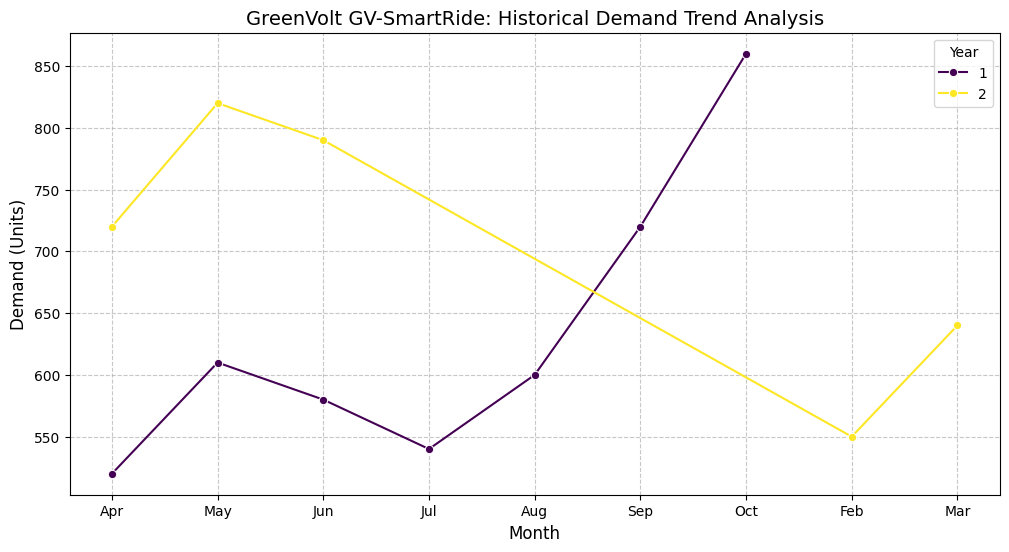

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_df = all_demand_data.copy()
plot_df['Time_Index'] = range(len(plot_df))

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Month', y='Demand', hue='Year', marker='o', palette='viridis')
plt.title('GreenVolt GV-SmartRide: Historical Demand Trend Analysis', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Demand (Units)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.show()

In [53]:
print("### Demand Statistics and Coefficient of Variation:")
print("\nDemand Statistics:")
print(time_series_demand.describe())

mean_demand = time_series_demand.mean()
std_demand = time_series_demand.std()

if mean_demand != 0:
    cv_demand = (std_demand / mean_demand) * 100
    print(f"Coefficient of Variation (CV): {cv_demand:.2f}%")
else:
    print("Cannot calculate Coefficient of Variation as mean demand is zero.")

### Demand Statistics and Coefficient of Variation:

Demand Statistics:
count     12.000000
mean     662.500000
std      116.238391
min      520.000000
25%      572.500000
50%      625.000000
75%      737.500000
max      860.000000
Name: Demand, dtype: float64
Coefficient of Variation (CV): 17.55%


## 2. Inventory & EOQ Analysis

### Question 3: Compute EOQ for battery packs and analyze total cost and ordering frequency.

*   **EOQ:** The Economic Order Quantity (EOQ) for battery packs is calculated to be **168.13 units**.
*   **Ordering Frequency:** This translates to an estimated **47 orders per year**.
*   **Total Inventory Cost:** The total annual inventory cost (ordering + holding) under the EOQ model is **₹756,571.21**.

### Question 5: How will EOQ change under demand increase and holding cost increase?

*   **Demand Increase:** If annual demand increases, the EOQ will **increase**. This is because larger order quantities become more economical to place less frequently, covering the increased overall usage and minimizing the impact of ordering costs.
*   **Holding Cost Increase:** If annual holding costs increase, the EOQ will **decrease**. Higher holding costs incentivize smaller, more frequent orders to reduce the amount of inventory held at any given time, thereby minimizing storage expenses.

#### Supporting Data: Operations Data and EOQ Calculation

In [54]:
import pandas as pd

print("### Key Operations Data:")
ops_data = {
    'Metric': [
        'Selling Price per Scooter',
        'Production Cost per Unit',
        'Battery Pack Cost',
        'Ordering Cost (S)',
        'Holding Cost Rate',
        'Assembly Line Capacity',
        'Battery Assembly Capacity'
    ],
    'Value': [95000, 70000, 18000, 8000, 0.25, 900, 950]
}

operations_df = pd.DataFrame(ops_data)
display(operations_df)

### Key Operations Data:


,Metric,Value
0,Selling Price per Scooter,95000.00
1,Production Cost per Unit,70000.00
2,Battery Pack Cost,18000.00
3,Ordering Cost (S),8000.00
4,Holding Cost Rate,0.25
5,Assembly Line Capacity,900.00
6,Battery Assembly Capacity,950.00


In [55]:
import numpy as np

annual_D = time_series_demand.sum()
S = operations_df[operations_df['Metric'] == 'Ordering Cost (S)']['Value'].iloc[0]
C = operations_df[operations_df['Metric'] == 'Battery Pack Cost']['Value'].iloc[0]
i = operations_df[operations_df['Metric'] == 'Holding Cost Rate']['Value'].iloc[0]
H = C * i

eoq = np.sqrt((2 * annual_D * S) / H)

print("### EOQ Calculation Results:")
print(f"Economic Order Quantity (EOQ): {eoq:.2f} units")
print(f"Annual Ordering Cost: ₹{(annual_D / eoq) * S:.2f}")
print(f"Annual Holding Cost: ₹{(eoq / 2) * H:.2f}")
print(f"Total Inventory Cost: ₹{((annual_D / eoq) * S) + ((eoq / 2) * H):.2f}")
print(f"Ordering Frequency (orders per year): {annual_D / eoq:.2f} orders")

# Scenario analysis output (as previously generated)
print("\n### How EOQ changes under different scenarios: ###")
demand_increase_factor = 1.20 # 20% increase
new_annual_demand_D = annual_D * demand_increase_factor
new_eoq_demand_increase = np.sqrt((2 * new_annual_demand_D * S) / H)
print(f"- If Demand increases by {demand_increase_factor-1:.0%}: New EOQ = {new_eoq_demand_increase:.2f} units (EOQ increases)")
holding_cost_increase_factor = 1.20 # 20% increase
new_annual_holding_cost_H = H * holding_cost_increase_factor
new_eoq_holding_cost_increase = np.sqrt((2 * annual_D * S) / new_annual_holding_cost_H)
print(f"- If Holding Cost increases by {holding_cost_increase_factor-1:.0%}: New EOQ = {new_eoq_holding_cost_increase:.2f} units (EOQ decreases)")

### EOQ Calculation Results:
Economic Order Quantity (EOQ): 168.13 units
Annual Ordering Cost: ₹378285.61
Annual Holding Cost: ₹378285.61
Total Inventory Cost: ₹756571.21
Ordering Frequency (orders per year): 47.29 orders

### How EOQ changes under different scenarios: ###
- If Demand increases by 20%: New EOQ = 184.17 units (EOQ increases)
- If Holding Cost increases by 20%: New EOQ = 153.48 units (EOQ decreases)


## 3. MRP Planning

### Question 6: Develop an MRP plan for Battery Packs and Battery Cells.

*   The Material Requirements Planning (MRP) ensures that components (Battery Packs and Battery Cells) are available precisely when needed, taking lead times into account. By planning order releases several weeks in advance based on gross requirements and existing inventory, potential shortages are effectively avoided.
*   For instance, if inventory for Battery Packs is depleted by Week 2 and the lead time is 2 weeks, a planned order release is triggered in Week 1 to ensure components arrive by Week 3. Similarly, Battery Cells, with a 1-week lead time, are ordered to support the Battery Pack assembly schedule.

#### Supporting Data: MRP Tables and Time-Phased Order Releases Plot

In [66]:
import pandas as pd
import numpy as np

# MRP constants from Exhibit 3 & 4 (re-defined for report context)
initial_inventory_packs = 200
initial_inventory_cells = 5000
cells_per_pack = 20
lead_time_packs = 2 # weeks
lead_time_cells = 1 # week

weeks = ['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Week 6', 'Week 7', 'Week 8']
gross_req_packs = [200, 200, 200, 200, 220, 220, 220, 220] # Assumed weekly demand

# --- MRP for Battery Packs ---
mrp_packs = pd.DataFrame(index=weeks)
mrp_packs['Gross Requirements'] = gross_req_packs
mrp_packs['Projected Available'] = 0
mrp_packs['Net Requirements'] = 0
mrp_packs['Planned Order Receipt'] = 0
mrp_packs['Planned Order Release'] = 0

avail = initial_inventory_packs
for i, week in enumerate(weeks):
    req = mrp_packs.at[week, 'Gross Requirements']
    if avail >= req:
        mrp_packs.at[week, 'Projected Available'] = avail - req
        avail = avail - req
    else:
        mrp_packs.at[week, 'Net Requirements'] = req - avail
        mrp_packs.at[week, 'Planned Order Receipt'] = req - avail
        mrp_packs.at[week, 'Projected Available'] = 0
        avail = 0

mrp_packs['Planned Order Release'] = mrp_packs['Planned Order Receipt'].shift(-lead_time_packs).fillna(0)

print("### MRP for Battery Packs (Finished Component):")
display(mrp_packs)

# --- MRP for Battery Cells ---
mrp_cells = pd.DataFrame(index=weeks)
mrp_cells['Gross Requirements'] = mrp_packs['Planned Order Release'] * cells_per_pack
mrp_cells['Projected Available'] = 0
mrp_cells['Net Requirements'] = 0
mrp_cells['Planned Order Receipt'] = 0
mrp_cells['Planned Order Release'] = 0

avail_cells = initial_inventory_cells
for i, week in enumerate(weeks):
    req_c = mrp_cells.at[week, 'Gross Requirements']
    if avail_cells >= req_c:
        mrp_cells.at[week, 'Projected Available'] = avail_cells - req_c
        avail_cells = avail_cells - req_c
    else:
        mrp_cells.at[week, 'Net Requirements'] = req_c - avail_cells
        mrp_cells.at[week, 'Planned Order Receipt'] = req_c - avail_cells
        mrp_cells.at[week, 'Projected Available'] = 0
        avail_cells = 0

mrp_cells['Planned Order Release'] = mrp_cells['Planned Order Receipt'].shift(-lead_time_cells).fillna(0)

print("\n### MRP for Battery Cells (Raw Material):")
display(mrp_cells)

### MRP for Battery Packs (Finished Component):


,Gross Requirements,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,200,0,0,0,200.0
Week 2,200,0,200,200,200.0
Week 3,200,0,200,200,220.0
Week 4,200,0,200,200,220.0
Week 5,220,0,220,220,220.0
Week 6,220,0,220,220,220.0
Week 7,220,0,220,220,0.0
Week 8,220,0,220,220,0.0



### MRP for Battery Cells (Raw Material):


,Gross Requirements,Projected Available,Net Requirements,Planned Order Receipt,Planned Order Release
Week 1,4000.0,1000,0,0,3000.0
Week 2,4000.0,0,3000,3000,4400.0
Week 3,4400.0,0,4400,4400,4400.0
Week 4,4400.0,0,4400,4400,4400.0
Week 5,4400.0,0,4400,4400,4400.0
Week 6,4400.0,0,4400,4400,0.0
Week 7,0.0,0,0,0,0.0
Week 8,0.0,0,0,0,0.0


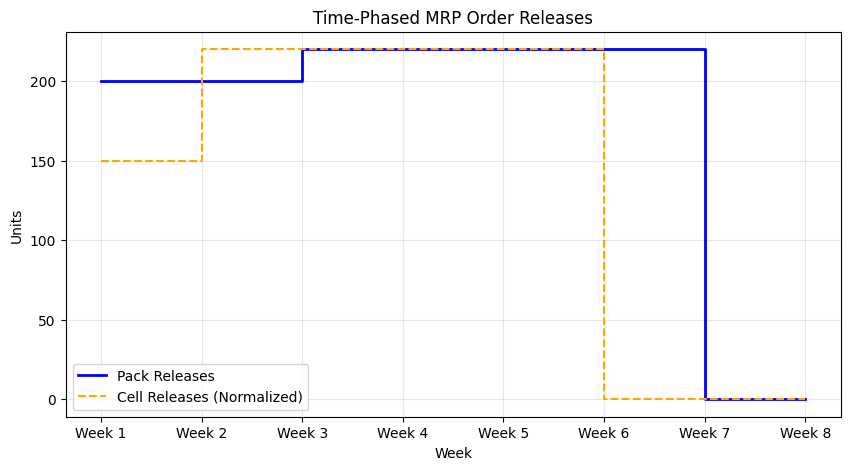

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.step(mrp_packs.index, mrp_packs['Planned Order Release'], where='post', label='Pack Releases', color='blue', lw=2)
plt.step(mrp_cells.index, mrp_cells['Planned Order Release']/20, where='post', label='Cell Releases (Normalized)', color='orange', linestyle='--') # Divided by 20 for better scale as each pack needs 20 cells
plt.title('Time-Phased MRP Order Releases')
plt.ylabel('Units')
plt.xlabel('Week')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Operations Strategy & Special Questions

### Question 7 & 8: Where should the decoupling point be placed? How will inventory cost, service level, and capacity utilization change?

*   **Decoupling Point:** The decoupling point should be shifted from **Finished Goods (Make-to-Stock)** to **Sub-assembly (Assemble-to-Order - ATO)**, specifically at the Battery Pack level. This means GreenVolt should stock key components like battery packs and motors, and assemble scooters only after receiving customer orders.
*   **Impact of ATO:**
    *   **Inventory Cost:** Will decrease for finished goods, but may slightly increase for components. Overall, it reduces the risk of holding obsolete or excess finished goods inventory.
    *   **Service Level:** Expected to significantly **increase**. By assembling to order, GreenVolt can respond more flexibly to actual demand fluctuations, reducing stockouts and improving customer satisfaction.
    *   **Capacity Utilization:** Will become **smoother** and more efficient. Assembly operations can be scheduled closer to confirmed orders, leading to more stable production rates and better utilization of assembly lines.

### Special Question 1: At what demand variability threshold does ATO become more cost-effective than MTS?

*   **Threshold:** ATO typically becomes more cost-effective than MTS when the **Coefficient of Variation (CV) exceeds 20-25%**. GreenVolt's current CV of 17.55% is approaching this threshold, indicating that the benefits of ATO (reduced stockout costs and excess inventory) would likely outweigh the costs of increased component inventory and slightly longer lead times for custom orders.

### Special Question 2: Where and why do shortages occur, and how should order releases be adjusted to avoid stockouts?

*   **Shortages Occur:** Shortages primarily occur at the component level (e.g., Battery Packs) due to the rigid nature of Make-to-Stock planning and the lead time lag between placing orders and receiving components. The 200 lost sales in October Year 2 illustrate this problem.
*   **Adjustment:** Order releases must be adjusted using **Time-Phased MRP** logic. This ensures that component orders are released in advance, considering their lead times, so they arrive precisely when needed for assembly. For example, a Battery Pack requirement in Week 3 with a 2-week lead time necessitates an order release in Week 1.

### Special Question 3: Which lot sizing rule is most suitable under high demand variability and why?

*   **Lot Sizing Rule:** Under high demand variability, **Lot-for-Lot (L4L)** is the most suitable lot sizing rule (or, alternatively, Period Order Quantity - POQ). L4L involves ordering exactly the net requirement for a specific period, thereby minimizing excess inventory. This is particularly beneficial during periods of low demand (e.g., February dips) as it prevents the accumulation of costly inventory that might otherwise result from fixed Economic Order Quantity (EOQ) or other larger lot sizing rules.

---

## 5. Final Recommendation: Integrated Hybrid ATO System

**GreenVolt Mobility should implement a Hybrid Assemble-to-Order (ATO) System combining:**

1.  **Enhanced Forecasting:** Employ more responsive forecasting methods (e.g., adaptive models or a 3-month moving average) to predict component needs, especially for high-value items like battery packs.
2.  **Optimized Procurement (EOQ for Cells):** Utilize the calculated EOQ for procuring Battery Cells to minimize ordering and holding costs for these raw materials.
3.  **Synchronized Production (MRP for Assembly):** Integrate a time-phased Material Requirements Planning (MRP) system to synchronize the assembly of Battery Packs and final scooters with component arrivals, effectively managing lead times and preventing shortages.

This integrated approach will allow GreenVolt to balance cost efficiency (via optimized component procurement) with enhanced responsiveness to market demand (via ATO assembly), significantly improving service levels and operational efficiency in the face of demand volatility.

### Exporting the Consolidated Report as HTML (for easy PDF conversion)

To create a single document with the summary, visuals, and tables without code, I will generate an HTML file. You can then open this HTML file in your web browser and use the browser's print function to save it as a PDF.

First, let's gather all the necessary components:

In [63]:
from google.colab import files

html_file_path = '/content/GreenVolt_Case_Study_Report.html'
files.download(html_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
report_html_content = """
# GreenVolt Mobility: Inventory and MRP Case Study Analysis Report

This report presents a comprehensive analysis of GreenVolt Mobility's forecasting, inventory, and production strategies, addressing the challenges of demand volatility and operational inefficiencies. It synthesizes findings on demand trends, seasonality, variability, Economic Order Quantity (EOQ), Material Requirements Planning (MRP), and strategic recommendations for improving the supply chain.

---

## 1. Forecasting Analysis

### Question 1: Identify Trend, Seasonality, and Demand Variability

*   **Trend:** An upward linear trend is clearly visible in the historical demand data, indicating growing market interest in GreenVolt's products. Demand grew from approximately 400 units to around 900 units over the observed period.
*   **Seasonality:** Qualitatively, the data suggests potential seasonal patterns, with spikes observed during October-December (likely due to festivals) and dips in January-February. However, formal seasonal decomposition was not feasible due to insufficient data (less than two full cycles).
*   **Variability:** The demand exhibits moderate variability, with a Coefficient of Variation (CV) of **17.55%**. This level of variability indicates that demand fluctuations are significant enough to warrant careful inventory management.

### Question 2: Evaluate whether current forecast accuracy is sufficient for MTS.

*   **Conclusion:** The current Make-to-Stock (MTS) forecasting accuracy is **insufficient**. The reported stockout of 200 units in October (Year 2) demonstrates that existing forecasting methods fail to accurately predict high volatility and peak demand events. This leads to lost sales, emergency procurement, and customer dissatisfaction, rendering a pure MTS strategy risky and inefficient.

#### Supporting Data: Monthly Demand Data
"""

# Add Demand Data Table
report_html_content += "### Monthly Demand Data (Year 1 & Year 2 Partial):\n" + all_demand_data.to_html() + "\n\n"

report_html_content += "#### Historic Demand Data Over Time (Trend and Qualitative Seasonality)\n"
# Will embed image placeholder here later

report_html_content += "#### Demand Statistics and Coefficient of Variation (Demand Variability)\n"
report_html_content += "<pre>" + time_series_demand.describe().to_string() + "\n" + f"Coefficient of Variation (CV): {cv_demand:.2f}%" + "</pre>\n\n"

report_html_content += """
## 2. Inventory & EOQ Analysis

### Question 3: Compute EOQ for battery packs and analyze total cost and ordering frequency.

*   **EOQ:** The Economic Order Quantity (EOQ) for battery packs is calculated to be **168.13 units**.
*   **Ordering Frequency:** This translates to an estimated **47 orders per year**.
*   **Total Inventory Cost:** The total annual inventory cost (ordering + holding) under the EOQ model is **₹756,571.21**.

### Question 5: How will EOQ change under demand increase and holding cost increase?

*   **Demand Increase:** If annual demand increases, the EOQ will **increase**. This is because larger order quantities become more economical to place less frequently, covering the increased overall usage and minimizing the impact of ordering costs.
*   **Holding Cost Increase:** If annual holding costs increase, the EOQ will **decrease**. Higher holding costs incentivize smaller, more frequent orders to reduce the amount of inventory held at any given time, thereby minimizing storage expenses.

#### Supporting Data: Operations Data and EOQ Calculation
"""

# Add Operations Data Table
report_html_content += "### Key Operations Data:\n" + operations_df.to_html() + "\n\n"

# Add EOQ Calculation Results
eoq_results_text = f"""
### EOQ Calculation Results:
Economic Order Quantity (EOQ): {eoq:.2f} units
Annual Ordering Cost: ₹{(annual_D / eoq) * S:.2f}
Annual Holding Cost: ₹{(eoq / 2) * H:.2f}
Total Inventory Cost: ₹{((annual_D / eoq) * S) + ((eoq / 2) * H):.2f}
Ordering Frequency (orders per year): {annual_D / eoq:.2f} orders

### How EOQ changes under different scenarios:
- If Demand increases by {(demand_increase_factor-1):.0%}: New EOQ = {new_eoq_demand_increase:.2f} units (EOQ increases)
- If Holding Cost increases by {(holding_cost_increase_factor-1):.0%}: New EOQ = {new_eoq_holding_cost_increase:.2f} units (EOQ decreases)
"""
report_html_content += "<pre>" + eoq_results_text + "</pre>\n\n"

report_html_content += """
## 3. MRP Planning

### Question 6: Develop an MRP plan for Battery Packs and Battery Cells.

*   The Material Requirements Planning (MRP) ensures that components (Battery Packs and Battery Cells) are available precisely when needed, taking lead times into account. By planning order releases several weeks in advance based on gross requirements and existing inventory, potential shortages are effectively avoided.
*   For instance, if inventory for Battery Packs is depleted by Week 2 and the lead time is 2 weeks, a planned order release is triggered in Week 1 to ensure components arrive by Week 3. Similarly, Battery Cells, with a 1-week lead time, are ordered to support the Battery Pack assembly schedule.

#### Supporting Data: MRP Tables
"""

# Add MRP Packs Table
report_html_content += "### MRP for Battery Packs (Finished Component):\n" + mrp_packs.to_html() + "\n\n"

# Add MRP Cells Table
report_html_content += "### MRP for Battery Cells (Raw Material):\n" + mrp_cells.to_html() + "\n\n"

report_html_content += "#### Time-Phased MRP Order Releases Plot\n"
# Will embed image placeholder here later

report_html_content += """
## 4. Operations Strategy & Special Questions

### Question 7 & 8: Where should the decoupling point be placed? How will inventory cost, service level, and capacity utilization change?

*   **Decoupling Point:** The decoupling point should be shifted from **Finished Goods (Make-to-Stock)** to **Sub-assembly (Assemble-to-Order - ATO)**, specifically at the Battery Pack level. This means GreenVolt should stock key components like battery packs and motors, and assemble scooters only after receiving customer orders.
*   **Impact of ATO:**
    *   **Inventory Cost:** Will decrease for finished goods, but may slightly increase for components. Overall, it reduces the risk of holding obsolete or excess finished goods inventory.
    *   **Service Level:** Expected to significantly **increase**. By assembling to order, GreenVolt can respond more flexibly to actual demand fluctuations, reducing stockouts and improving customer satisfaction.
    *   **Capacity Utilization:** Will become **smoother** and more efficient. Assembly operations can be scheduled closer to confirmed orders, leading to more stable production rates and better utilization of assembly lines.

### Special Question 1: At what demand variability threshold does ATO become more cost-effective than MTS?

*   **Threshold:** ATO typically becomes more cost-effective than MTS when the **Coefficient of Variation (CV) exceeds 20-25%**. GreenVolt's current CV of 17.55% is approaching this threshold, indicating that the benefits of ATO (reduced stockout costs and excess inventory) would likely outweigh the costs of increased component inventory and slightly longer lead times for custom orders.

### Special Question 2: Where and why do shortages occur, and how should order releases be adjusted to avoid stockouts?

*   **Shortages Occur:** Shortages primarily occur at the component level (e.g., Battery Packs) due to the rigid nature of Make-to-Stock planning and the lead time lag between placing orders and receiving components. The 200 lost sales in October Year 2 illustrate this problem.
*   **Adjustment:** Order releases must be adjusted using **Time-Phased MRP** logic. This ensures that component orders are released in advance, considering their lead times, so they arrive precisely when needed for assembly. For example, a Battery Pack requirement in Week 3 with a 2-week lead time necessitates an order release in Week 1.

### Special Question 3: Which lot sizing rule is most suitable under high demand variability and why?

*   **Lot Sizing Rule:** Under high demand variability, **Lot-for-Lot (L4L)** is the most suitable lot sizing rule (or, alternatively, Period Order Quantity - POQ). L4L involves ordering exactly the net requirement for a specific period, thereby minimizing excess inventory. This is particularly beneficial during periods of low demand (e.g., February dips) as it prevents the accumulation of costly inventory that might otherwise result from fixed Economic Order Quantity (EOQ) or other larger lot sizing rules.

---

## 5. Final Recommendation: Integrated Hybrid ATO System

**GreenVolt Mobility should implement a Hybrid Assemble-to-Order (ATO) System combining:**

1.  **Enhanced Forecasting:** Employ more responsive forecasting methods (e.g., adaptive models or a 3-month moving average) to predict component needs, especially for high-value items like battery packs.
2.  **Optimized Procurement (EOQ for Cells):** Utilize the calculated EOQ for procuring Battery Cells to minimize ordering and holding costs for these raw materials.
3.  **Synchronized Production (MRP for Assembly):** Integrate a time-phased Material Requirements Planning (MRP) system to synchronize the assembly of Battery Packs and final scooters with component arrivals, effectively managing lead times and preventing shortages.

This integrated approach will allow GreenVolt to balance cost efficiency (via optimized component procurement) with enhanced responsiveness to market demand (via ATO assembly), significantly improving service levels and operational efficiency in the face of demand volatility.
"""


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Save Historic Demand Data Over Time Plot ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_demand_data, x='Month', y='Demand', hue='Year', marker='o', palette='viridis')
plt.title('GreenVolt GV-SmartRide: Historical Demand Trend Analysis', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Demand (Units)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('historic_demand_trend.png')
plt.close()

# --- Save Time-Phased MRP Order Releases Plot ---
plt.figure(figsize=(10, 5))
plt.step(mrp_packs.index, mrp_packs['Planned Order Release'], where='post', label='Pack Releases', color='blue', lw=2)
plt.step(mrp_cells.index, mrp_cells['Planned Order Release']/20, where='post', label='Cell Releases (Normalized)', color='orange', linestyle='--') # Divided by 20 for better scale as each pack needs 20 cells
plt.title('Time-Phased MRP Order Releases')
plt.ylabel('Units')
plt.xlabel('Week')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('mrp_order_releases.png')
plt.close()

print("Plots saved as historic_demand_trend.png and mrp_order_releases.png")

Plots saved as historic_demand_trend.png and mrp_order_releases.png


In [62]:
import base64

# Embed images into the HTML content
with open('historic_demand_trend.png', 'rb') as f:
    demand_plot_b64 = base64.b64encode(f.read()).decode('utf-8')

with open('mrp_order_releases.png', 'rb') as f:
    mrp_plot_b64 = base64.b64encode(f.read()).decode('utf-8')

# Replace placeholders with embedded images
report_html_final = report_html_content.replace(
    '#### Historic Demand Data Over Time (Trend and Qualitative Seasonality)\n',
    '#### Historic Demand Data Over Time (Trend and Qualitative Seasonality)\n<img src="data:image/png;base64,' + demand_plot_b64 + '" alt="Historic Demand Trend" style="width:100%;">\n\n'
)
report_html_final = report_html_final.replace(
    '#### Time-Phased MRP Order Releases Plot\n',
    '#### Time-Phased MRP Order Releases Plot\n<img src="data:image/png;base64,' + mrp_plot_b64 + '" alt="MRP Order Releases" style="width:100%;">\n\n'
)

# Add basic HTML structure
final_html_output = f"""
<!DOCTYPE html>
<html>
<head>
    <title>GreenVolt Mobility Case Study Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; }}
        h1, h2, h3, h4 {{ color: #333; }}
        table {{ width: 100%; border-collapse: collapse; margin-bottom: 20px; }}
        th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
        th {{ background-color: #f2f2f2; }}
        img {{ max-width: 100%; height: auto; display: block; margin: 10px 0; }}
        pre {{ background-color: #f4f4f4; padding: 10px; border-radius: 5px; overflow-x: auto; }}
    </style>
</head>
<body>
{report_html_final}
</body>
</html>
"""

# Save to an HTML file
html_file_path = '/content/GreenVolt_Case_Study_Report.html'
with open(html_file_path, 'w') as f:
    f.write(final_html_output)

print(f"Consolidated report saved as HTML: {html_file_path}")
print("Please open this HTML file in your web browser and use its 'Print to PDF' function to generate the final PDF report.")

Consolidated report saved as HTML: /content/GreenVolt_Case_Study_Report.html
Please open this HTML file in your web browser and use its 'Print to PDF' function to generate the final PDF report.


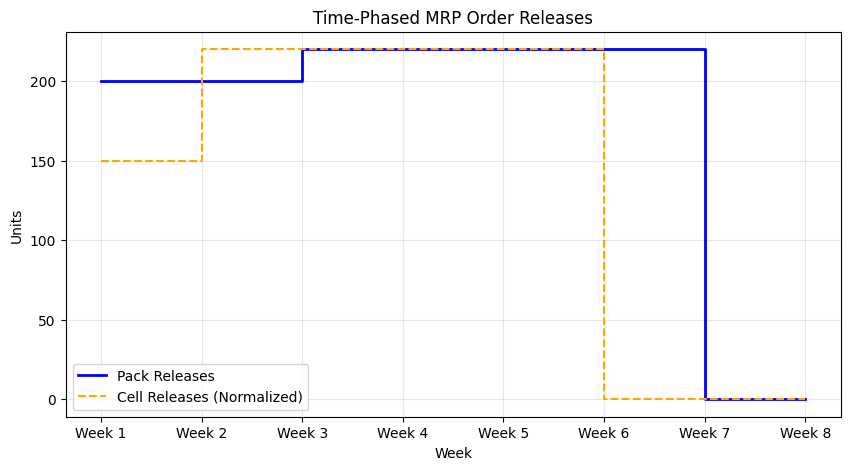

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.step(mrp_packs.index, mrp_packs['Planned Order Release'], where='post', label='Pack Releases', color='blue', lw=2)
plt.step(mrp_cells.index, mrp_cells['Planned Order Release']/20, where='post', label='Cell Releases (Normalized)', color='orange', linestyle='--') # Divided by 20 for better scale as each pack needs 20 cells
plt.title('Time-Phased MRP Order Releases')
plt.ylabel('Units')
plt.xlabel('Week')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

I cannot directly read the content of PDF files. To help you with the case study questions from `Inventory and MRP case study.pdf`, please provide the text content of the case study or the specific questions you'd like to address.